In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("ecommerce_customer_behavior.csv")

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [5]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
Purchase                    0
dtype: int64

Text(0.5, 1.0, 'Customer is likely purchase or not?')

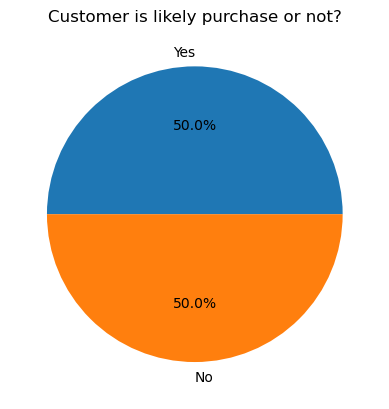

In [6]:

count = df["Purchase"].value_counts()
plt.pie(
    count,
    labels=count.index,
    autopct="%1.1f%%"
)
plt.title("Customer is likely purchase or not?")


Gender
Female    2492
Male      2435
Other       73
Name: count, dtype: int64


[Text(0, 0, '2492'), Text(0, 0, '2435'), Text(0, 0, '73')]

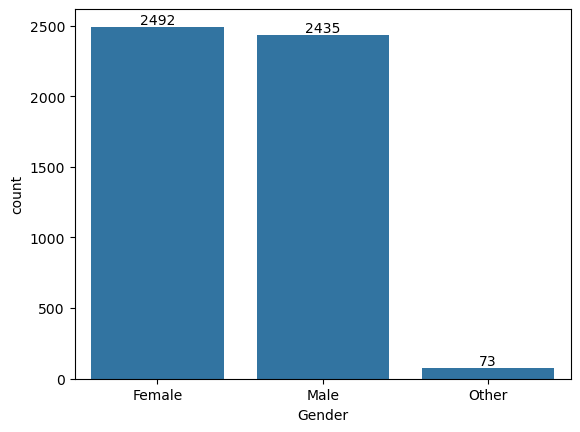

In [7]:
gender_count = df["Gender"].value_counts()
print(gender_count)
ax = sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

Payment_Method
Credit Card         2012
Debit Card          1265
Digital Wallet       965
Bank Transfer        510
Cash on Delivery     248
Name: count, dtype: int64


[Text(0, 0, '2012'),
 Text(0, 0, '1265'),
 Text(0, 0, '965'),
 Text(0, 0, '510'),
 Text(0, 0, '248')]

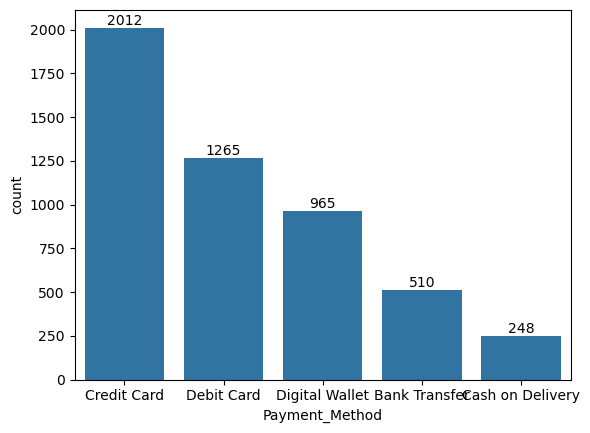

In [8]:
Payment_Method_count = df["Payment_Method"].value_counts()
print(Payment_Method_count)
ax = sns.barplot(Payment_Method_count)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Purchase', ylabel='Age'>

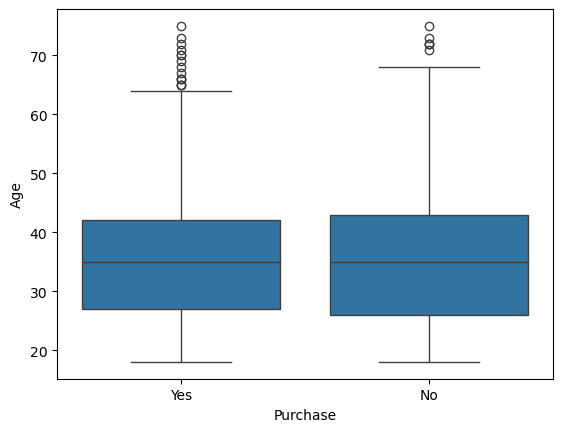

In [9]:
sns.boxplot(
    data = df,
    x = "Purchase",
    y = "Age"
)

City
Istanbul     1284
Ankara        735
Izmir         600
Bursa         496
Adana         378
Antalya       374
Gaziantep     349
Konya         317
Kayseri       257
Eskisehir     210
Name: count, dtype: int64


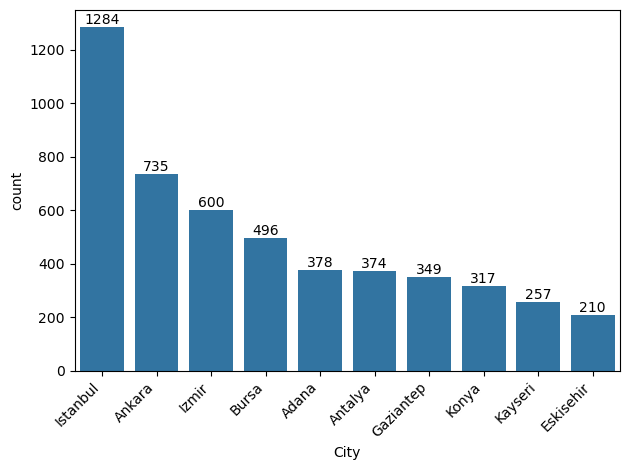

In [10]:
City_count = df["City"].value_counts()
print(City_count)
ax = sns.barplot(City_count)
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

Product_Category
Sports           667
Electronics      624
Fashion          622
Beauty           621
Home & Garden    621
Food             619
Books            616
Toys             610
Name: count, dtype: int64


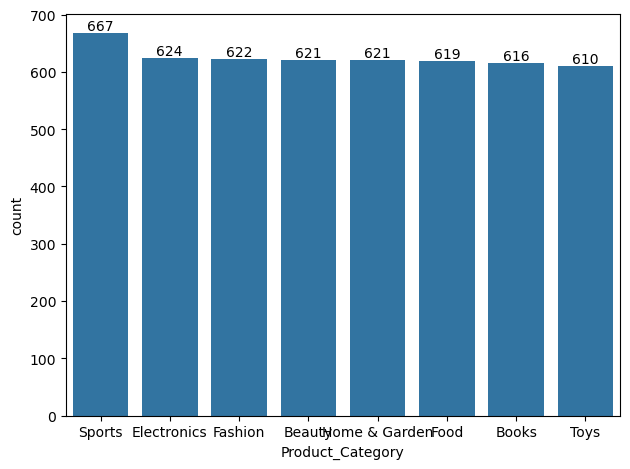

In [11]:
Product_Category_count = df["Product_Category"].value_counts()
print(Product_Category_count)
ax = sns.barplot(Product_Category_count)
ax.bar_label(ax.containers[0])
plt.tight_layout()

In [12]:
# encoding
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [13]:
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Purchase
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,Yes
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,No
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,No
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,No
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,Yes


In [14]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()

df["Purchase"] = le.fit_transform(df["Purchase"])

In [15]:
df.head(10)

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Purchase
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,1
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,0
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,0
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,0
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,1
5,ORD_000223,CUST_00223,2023-01-01,43,Female,Istanbul,Beauty,122.46,1,0.00,122.46,Credit Card,Mobile,14,9,True,9,5,0
6,ORD_002506,CUST_02506,2023-01-01,25,Female,Izmir,Electronics,2107.37,2,0.00,4214.74,Digital Wallet,Desktop,10,5,False,6,5,0
7,ORD_004540,CUST_04540,2023-01-01,44,Male,Konya,Food,213.64,2,0.00,427.28,Credit Card,Mobile,10,16,False,3,5,1
8,ORD_001808,CUST_01808,2023-01-02,41,Male,Istanbul,Fashion,257.62,5,62.15,1225.95,Credit Card,Tablet,24,7,False,2,4,1
9,ORD_003413,CUST_03413,2023-01-02,58,Male,Istanbul,Sports,1784.75,4,490.25,6648.75,Debit Card,Desktop,8,5,True,5,4,0


In [16]:
cols = ["Gender","City","Product_Category","Payment_Method","Device_Type","Is_Returning_Customer"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=df.index)
df = pd.concat([df.drop(columns=cols), encoded_df], axis=1)

In [17]:
encoded

array([[0., 0., 0., ..., 1., 0., 1.],
       [1., 0., 0., ..., 1., 0., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       ...,
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], shape=(5000, 25))

In [22]:
df.head()

,Order_ID,Customer_ID,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,...,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet,Device_Type_Mobile,Device_Type_Tablet,Is_Returning_Customer_True
0,ORD_001337,CUST_01337,2023-01-01,27,54.28,1,0.00,54.28,4,14,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,ORD_004885,CUST_04885,2023-01-01,42,244.90,1,0.00,244.90,11,3,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,ORD_004507,CUST_04507,2023-01-01,43,48.15,5,0.00,240.75,7,8,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
3,ORD_000645,CUST_00645,2023-01-01,32,804.06,1,229.28,574.78,8,10,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,ORD_000690,CUST_00690,2023-01-01,40,755.61,5,0.00,3778.05,21,10,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 38 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Order_ID                         5000 non-null   object 
 1   Customer_ID                      5000 non-null   object 
 2   Date                             5000 non-null   object 
 3   Age                              5000 non-null   int64  
 4   Unit_Price                       5000 non-null   float64
 5   Quantity                         5000 non-null   int64  
 6   Discount_Amount                  5000 non-null   float64
 7   Total_Amount                     5000 non-null   float64
 8   Session_Duration_Minutes         5000 non-null   int64  
 9   Pages_Viewed                     5000 non-null   int64  
 10  Delivery_Time_Days               5000 non-null   int64  
 11  Customer_Rating                  5000 non-null   int64  
 12  Purchase            

In [24]:
X = df.drop(columns=["Order_ID","Customer_ID","Date","Purchase"])
y = df["Purchase"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# logistic 
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

print("Precision :", precision_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))

Precision : 0.8821138211382114
recall : 0.9022869022869023
f1 : 0.8920863309352518
accuracy : 0.895


In [27]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

print("Precision :", precision_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))

Precision : 0.6940451745379876
recall : 0.7027027027027027
f1 : 0.6983471074380165
accuracy : 0.708


In [33]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

y_pred = nb_model.predict(X_test_scaled)

print("Precision :", precision_score(y_test, y_pred))
print("recall :", recall_score(y_test, y_pred))
print("f1 :", f1_score(y_test, y_pred))
print("accuracy :", accuracy_score(y_test, y_pred))

Precision : 0.8509316770186336
recall : 0.8544698544698545
f1 : 0.8526970954356846
accuracy : 0.858
